In [7]:
# Mount Drive & Import Libraries
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

df = pd.read_excel('/content/drive/MyDrive/Datasets/Decodelab Internship/Cleaned_Dataset.xlsx')

# Fill the CouponCode NaN (only remaining step)
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

# Parse dates & add helper columns
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.strftime('%b')
df['YearMonth'] = df['Date'].dt.to_period('M')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Descriptive Statistics — The Five-Number Summary <a id='4-stats'></a>

### What is the Five-Number Summary?
The five-number summary is the *skeleton* of any numeric variable:

| Statistic | Meaning |
|-----------|---------|
| **Min** | The floor — lowest value |
| **Q1 (25th percentile)** | Bottom quarter of data |
| **Median (Q2 / 50th)** | The true center — resistant to outliers |
| **Q3 (75th percentile)** | Top quarter of data |
| **Max** | The ceiling — highest value |

We also look at **mean** and **standard deviation** to understand spread.

> **Key insight:** If mean >> median, the data is *right-skewed* (pulled up by high values).  
> If mean << median, the data is *left-skewed*.


In [8]:
# Full descriptive statistics for numerical columns
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
desc = df[numeric_cols].describe().round(2)
desc.loc['median'] = df[numeric_cols].median().round(2)
desc.loc['skewness'] = df[numeric_cols].skew().round(2)
print("Descriptive Statistics:")
desc

Descriptive Statistics:


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.00,1200.00,1200.00,1200.00
mean,2.95,356.41,5.48,1053.97
std,1.41,197.18,2.28,819.86
min,1.00,11.39,1.00,11.39
25%,2.00,186.06,4.00,410.52
50%,3.00,364.21,5.00,823.62
75%,4.00,521.57,7.00,1578.48
max,5.00,699.93,10.00,3456.40
median,3.00,364.21,5.00,823.62
skewness,0.03,-0.03,0.00,0.89


In [9]:
# Interpret skewness
for col in ['TotalPrice', 'UnitPrice']:
    mean_val = df[col].mean()
    median_val = df[col].median()
    skew_val = df[col].skew()
    direction = "RIGHT-skewed ↗ (mean pulled up by large values)" if skew_val > 0.5 else                 "LEFT-skewed ↙ (mean pulled down)" if skew_val < -0.5 else "Approximately symmetric ↔"
    print(f"  {col}: mean={mean_val:.2f}, median={median_val:.2f}, skew={skew_val:.3f} → {direction}")


  TotalPrice: mean=1053.97, median=823.62, skew=0.891 → RIGHT-skewed ↗ (mean pulled up by large values)
  UnitPrice: mean=356.41, median=364.21, skew=-0.027 → Approximately symmetric ↔


---
## Univariate Analysis — Distribution of Key Variables <a id='5-univariate'></a>

**Univariate analysis** examines one variable at a time to understand its shape (distribution).

We ask: *What is the geometry of this evidence?*

- A **symmetric (bell-shaped)** distribution → mean is a reliable summary
- A **skewed distribution** → median is more trustworthy than mean
- **Multiple peaks** → possible sub-groups exist in the data


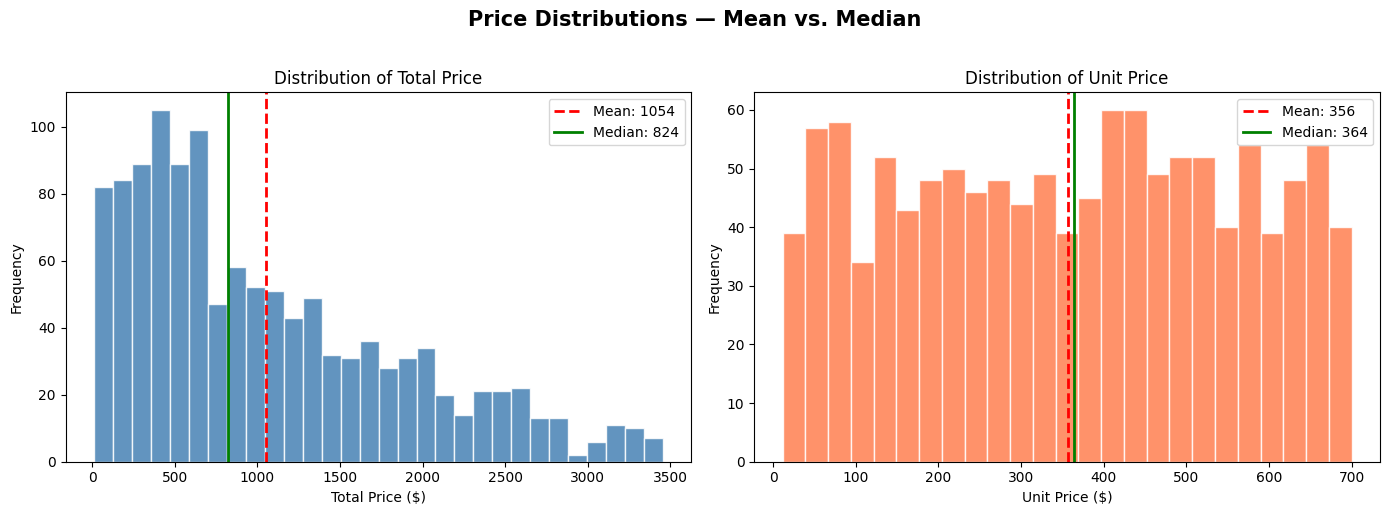

Observation: If the red dashed line (mean) is to the RIGHT of the green line (median), the data is right-skewed.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TotalPrice distribution
axes[0].hist(df['TotalPrice'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['TotalPrice'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['TotalPrice'].mean():.0f}")
axes[0].axvline(df['TotalPrice'].median(), color='green', linestyle='-', linewidth=2, label=f"Median: {df['TotalPrice'].median():.0f}")
axes[0].set_title('Distribution of Total Price')
axes[0].set_xlabel('Total Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# UnitPrice distribution
axes[1].hist(df['UnitPrice'], bins=25, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(df['UnitPrice'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['UnitPrice'].mean():.0f}")
axes[1].axvline(df['UnitPrice'].median(), color='green', linestyle='-', linewidth=2, label=f"Median: {df['UnitPrice'].median():.0f}")
axes[1].set_title('Distribution of Unit Price')
axes[1].set_xlabel('Unit Price ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Price Distributions — Mean vs. Median', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Decodelab Internship/price_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Observation: If the red dashed line (mean) is to the RIGHT of the green line (median), the data is right-skewed.")


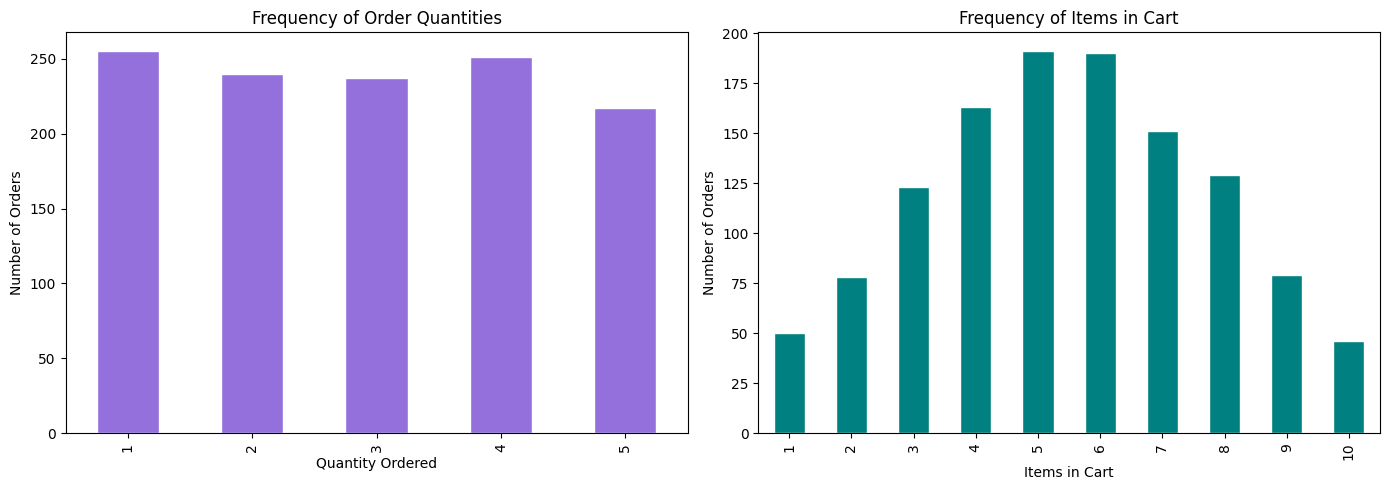

In [11]:
# Quantity & ItemsInCart distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Quantity'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Frequency of Order Quantities')
axes[0].set_xlabel('Quantity Ordered')
axes[0].set_ylabel('Number of Orders')

df['ItemsInCart'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Frequency of Items in Cart')
axes[1].set_xlabel('Items in Cart')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Decodelab Internship/quantity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Bivariate & Categorical Analysis <a id='6-bivariate'></a>

Now we compare variables against each other — asking *"What drives revenue?"*

### Questions we investigate:
1. Which **product** generates the most total revenue?
2. Which **payment method** is most popular?
3. How does **order status** break down? (are many orders cancelled?)
4. Which **referral source** brings the most customers?
5. Does using a **coupon** affect order value?


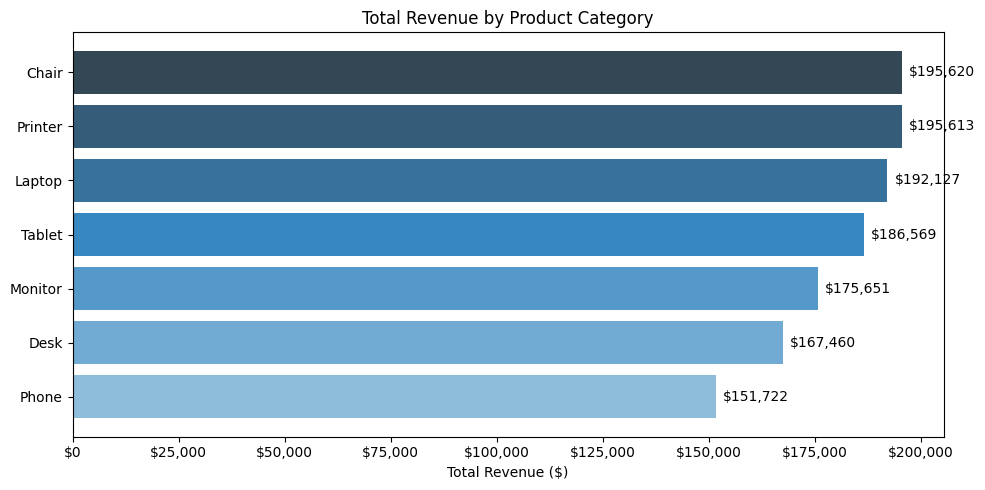

Top Revenue Product: Chair ($195,620.11)


In [13]:
import matplotlib.ticker as mticker

# ── Revenue by Product ──
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(product_revenue.index, product_revenue.values, color=sns.color_palette('Blues_d', len(product_revenue)))
ax.bar_label(bars, labels=[f'${v:,.0f}' for v in product_revenue.values], padding=5)
ax.set_title('Total Revenue by Product Category')
ax.set_xlabel('Total Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Decodelab Internship/revenue_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

top_product = product_revenue.idxmax()
print(f"Top Revenue Product: {top_product} (${product_revenue.max():,.2f})")


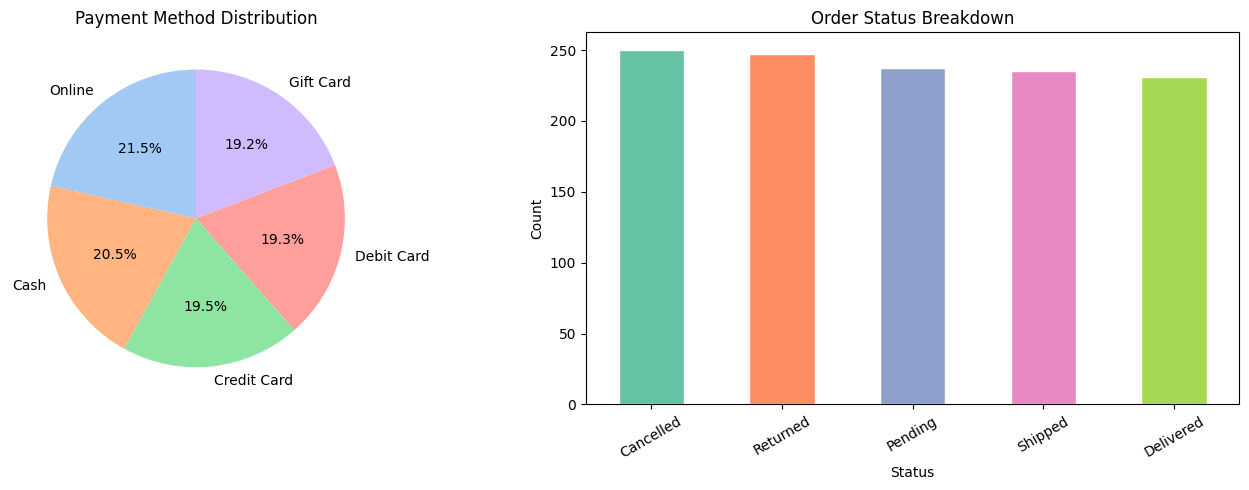

 Cancelled orders: 250 (20.8%)
 Returned orders:  247 (20.6%)


In [14]:
# ── Payment Method & Order Status ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pay_counts = df['PaymentMethod'].value_counts()
axes[0].pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('pastel'))
axes[0].set_title('Payment Method Distribution')

status_counts = df['OrderStatus'].value_counts()
status_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2'), edgecolor='white')
axes[1].set_title('Order Status Breakdown')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Decodelab Internship/payment_status.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Cancelled orders: {status_counts.get('Cancelled', 0)} ({status_counts.get('Cancelled', 0)/len(df)*100:.1f}%)")
print(f" Returned orders:  {status_counts.get('Returned', 0)} ({status_counts.get('Returned', 0)/len(df)*100:.1f}%)")


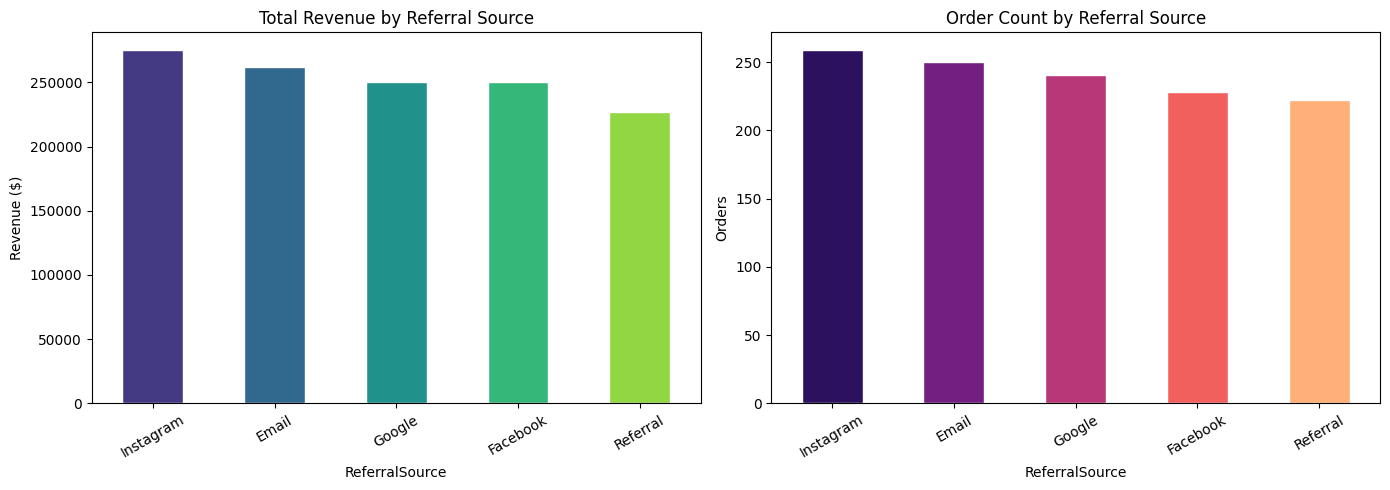

In [15]:
# ── Referral Source ──
ref_revenue = df.groupby('ReferralSource')['TotalPrice'].agg(['sum','count']).sort_values('sum', ascending=False)
ref_revenue.columns = ['Total Revenue', 'Order Count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ref_revenue['Total Revenue'].plot(kind='bar', ax=axes[0], color=sns.color_palette('viridis', 5), edgecolor='white')
axes[0].set_title('Total Revenue by Referral Source')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=30)

ref_revenue['Order Count'].plot(kind='bar', ax=axes[1], color=sns.color_palette('magma', 5), edgecolor='white')
axes[1].set_title('Order Count by Referral Source')
axes[1].set_ylabel('Orders')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Decodelab Internship/referral_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


  Coupon Code Impact on Average Order Value:
            Avg Order Value ($)  Order Count
CouponCode                                  
FREESHIP                1070.41          313
SAVE10                  1065.87          286
No Coupon               1043.37          309
WINTER15                1035.90          292


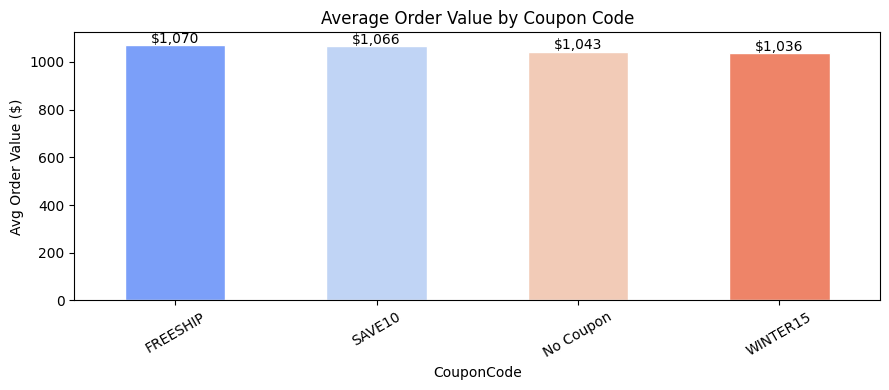

In [16]:
# ── Coupon Code Impact on Order Value ──
coupon_analysis = df.groupby('CouponCode')['TotalPrice'].agg(['mean','count']).round(2)
coupon_analysis.columns = ['Avg Order Value ($)', 'Order Count']
coupon_analysis = coupon_analysis.sort_values('Avg Order Value ($)', ascending=False)

print("  Coupon Code Impact on Average Order Value:")
print(coupon_analysis.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
coupon_analysis['Avg Order Value ($)'].plot(kind='bar', ax=ax, color=sns.color_palette('coolwarm', len(coupon_analysis)), edgecolor='white')
ax.set_title('Average Order Value by Coupon Code')
ax.set_ylabel('Avg Order Value ($)')
ax.tick_params(axis='x', rotation=30)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'${bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Decodelab Internship/coupon_impact.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Trend Analysis — Sales Over Time <a id='7-trend'></a>

Trend analysis reveals whether the business is growing, shrinking, or seasonal.  
We look at:
- **Monthly revenue trend** — overall direction
- **Revenue by year** — year-over-year comparison
- **Best and worst months**

> A rising trend is a green signal. A sudden drop is an alert — investigate *why*.


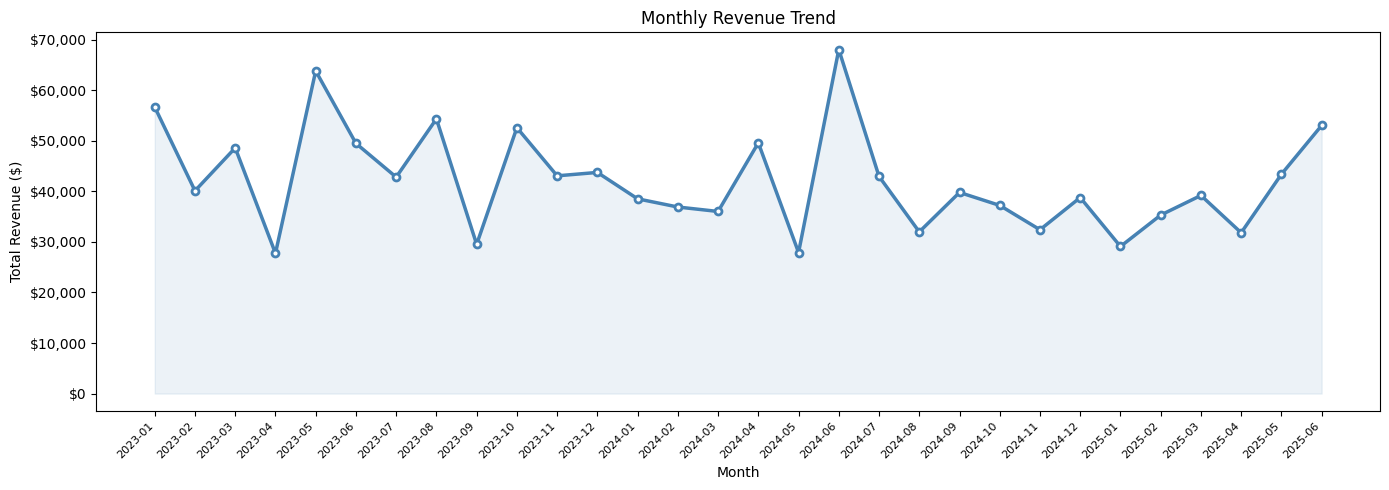

 Peak month: 2024-06 — $68,068.54


In [17]:
# Monthly revenue trend
monthly = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['YearMonth_str'], monthly['TotalPrice'], marker='o', linewidth=2.5,
        color='steelblue', markersize=5, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(range(len(monthly)), monthly['TotalPrice'], alpha=0.1, color='steelblue')
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
plt.xticks(range(len(monthly)), monthly['YearMonth_str'], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Decodelab Internship/monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

peak = monthly.loc[monthly['TotalPrice'].idxmax()]
print(f" Peak month: {peak['YearMonth_str']} — ${peak['TotalPrice']:,.2f}")


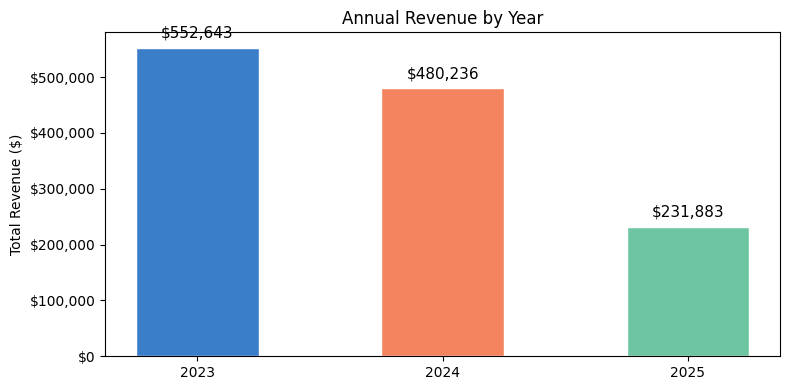

In [18]:
# Revenue by year
yearly = df.groupby('Year')['TotalPrice'].sum()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(yearly.index.astype(str), yearly.values, color=['#3A7DC9','#F4845F','#6DC5A1'], edgecolor='white', width=0.5)
ax.bar_label(bars, labels=[f'${v:,.0f}' for v in yearly.values], padding=5, fontsize=11)
ax.set_title('Annual Revenue by Year')
ax.set_ylabel('Total Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Decodelab Internship/annual_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Outlier Detection — IQR Method <a id='8-outliers'></a>

### What is an outlier?
An outlier is a data point that lies far outside the normal range of the data.

### The IQR Method (Interquartile Range)
This is the most robust method for business data (not sensitive to extreme values):

```
IQR = Q3 − Q1
Lower Bound = Q1 − 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR
```

Any value outside these bounds is flagged as a **suspect**.

### Noise vs. Signal
- **Noise (Error):** Data entry mistakes, typos → *Clean / Remove*
- **Signal (Insight):** VIP customers, bulk orders, fraud signals → *Investigate*

We visualize outliers using **boxplots** — the fingerprint of variability.


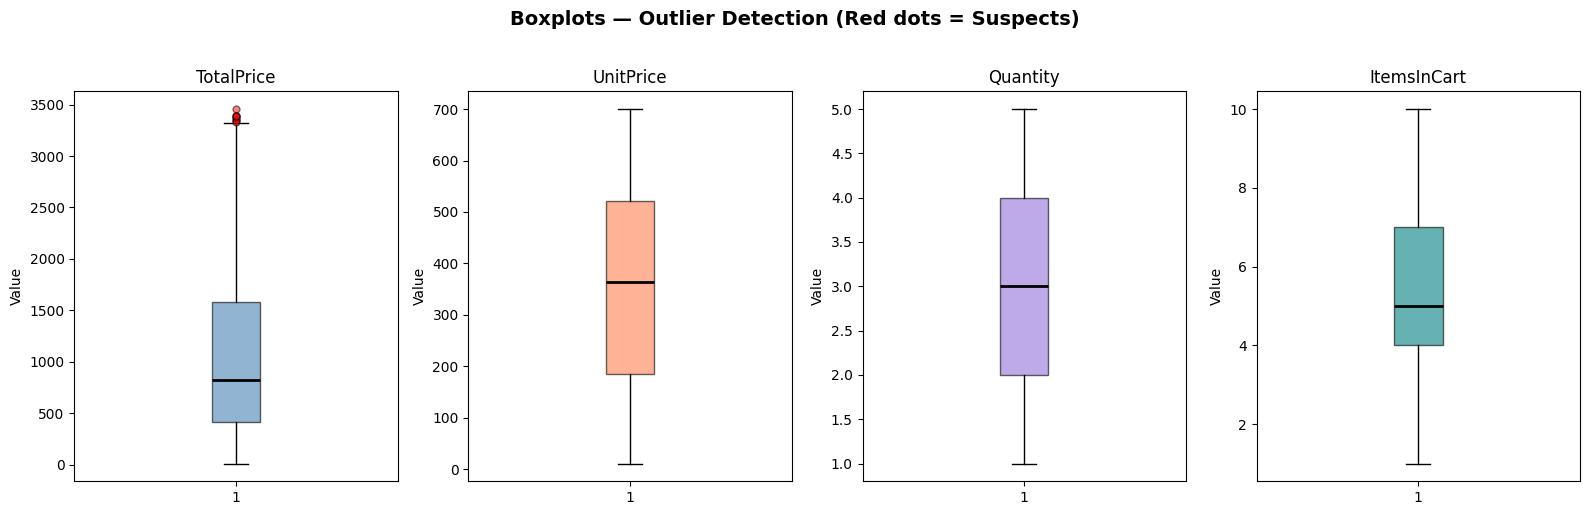

In [19]:
# Boxplots for numeric columns
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
cols = ['TotalPrice', 'UnitPrice', 'Quantity', 'ItemsInCart']
colors = ['steelblue', 'coral', 'mediumpurple', 'teal']

for ax, col, color in zip(axes, cols, colors):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.suptitle('Boxplots — Outlier Detection (Red dots = Suspects)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Decodelab Internship/boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# IQR outlier count for TotalPrice
def detect_outliers_iqr(series, label):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"    {label}")
    print(f"     Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"     Lower fence={lower:.2f}, Upper fence={upper:.2f}")
    print(f"     Outliers detected: {len(outliers)} ({len(outliers)/len(series)*100:.1f}%)")
    print(f"     Range of outlier values: {outliers.min():.2f} – {outliers.max():.2f}")
    print()
    return outliers

print(" IQR Outlier Analysis:")
print("="*50)
for col in ['TotalPrice', 'UnitPrice']:
    detect_outliers_iqr(df[col], col)


 IQR Outlier Analysis:
    TotalPrice
     Q1=410.52, Q3=1578.47, IQR=1167.95
     Lower fence=-1341.41, Upper fence=3330.41
     Outliers detected: 8 (0.7%)
     Range of outlier values: 3334.00 – 3456.40

    UnitPrice
     Q1=186.06, Q3=521.57, IQR=335.51
     Lower fence=-317.20, Upper fence=1024.83
     Outliers detected: 0 (0.0%)
     Range of outlier values: nan – nan



---
## Correlation Analysis <a id='9-correlation'></a>

Correlation measures **how strongly two variables move together**.

| Pearson r value | Interpretation |
|----------------|---------------|
| +1.0 | Perfect positive relationship |
| +0.7 to +0.99 | Strong positive |
| +0.3 to +0.69 | Moderate positive |
| 0 | No relationship |
| −0.3 to −0.69 | Moderate negative |
| −1.0 | Perfect negative |

### The Golden Rule: Correlation ≠ Causation
A correlation is a **clue**, not a **verdict**. Always check for hidden (confounding) variables.


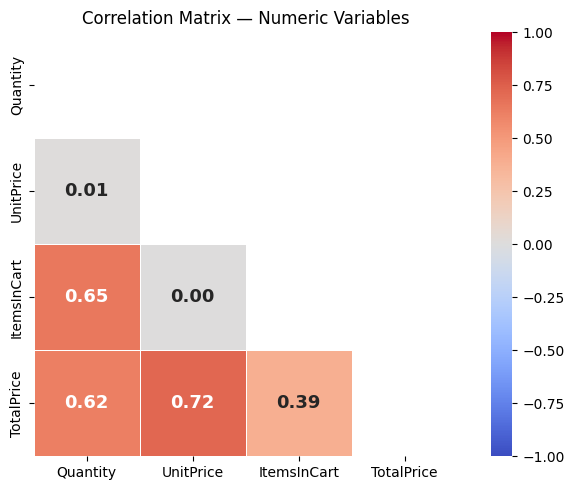

 Key Correlations:
  UnitPrice vs Quantity: r=0.01 → Weak positive ↗
  ItemsInCart vs Quantity: r=0.65 → Moderate positive ↗
  ItemsInCart vs UnitPrice: r=0.00 → Weak negative ↘
  TotalPrice vs Quantity: r=0.62 → Moderate positive ↗
  TotalPrice vs UnitPrice: r=0.72 → Strong positive ↗
  TotalPrice vs ItemsInCart: r=0.39 → Moderate positive ↗


In [21]:
# Correlation heatmap
corr_matrix = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1, mask=mask,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('Correlation Matrix — Numeric Variables')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Decodelab Internship/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Key Correlations:")
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        c1, c2 = corr_matrix.columns[i], corr_matrix.columns[j]
        strength = "Strong" if abs(val) >= 0.7 else "Moderate" if abs(val) >= 0.3 else "Weak"
        direction = "positive ↗" if val > 0 else "negative ↘"
        print(f"  {c1} vs {c2}: r={val:.2f} → {strength} {direction}")


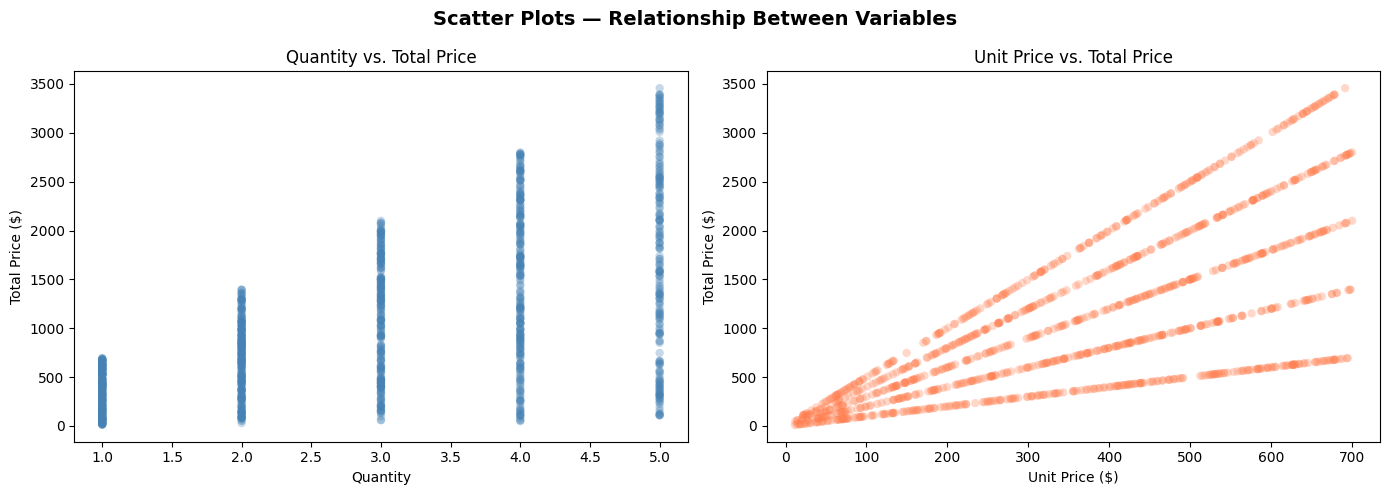

In [22]:
# Scatter: Quantity vs TotalPrice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Quantity'], df['TotalPrice'], alpha=0.3, color='steelblue', edgecolors='none')
axes[0].set_title('Quantity vs. Total Price')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Total Price ($)')

axes[1].scatter(df['UnitPrice'], df['TotalPrice'], alpha=0.3, color='coral', edgecolors='none')
axes[1].set_title('Unit Price vs. Total Price')
axes[1].set_xlabel('Unit Price ($)')
axes[1].set_ylabel('Total Price ($)')

plt.suptitle('Scatter Plots — Relationship Between Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Decodelab Internship/scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Executive Summary & Business Insights <a id='10-summary'></a>

This section answers the **"So What?" Test** — translating statistical findings into business language.

> *Don't say "Mean churn increased by 3%." Say "We lost 1,510 customers — equivalent to closing 11 retail stores."*


In [25]:
# ── Compute all key metrics ──
total_revenue      = df['TotalPrice'].sum()
avg_order_value    = df['TotalPrice'].mean()
median_order_value = df['TotalPrice'].median()
total_orders       = len(df)
cancelled_pct      = (df['OrderStatus'] == 'Cancelled').mean() * 100
returned_pct       = (df['OrderStatus'] == 'Returned').mean() * 100
top_product        = df.groupby('Product')['TotalPrice'].sum().idxmax()
top_referral       = df.groupby('ReferralSource')['TotalPrice'].sum().idxmax()
coupon_avg         = df[df['CouponCode'] != 'No Coupon']['TotalPrice'].mean()
no_coupon_avg      = df[df['CouponCode'] == 'No Coupon']['TotalPrice'].mean()

print("=" * 60)
print("       EXECUTIVE SUMMARY - EDA REPORT")
print("=" * 60)
print("\n  DATASET")
print(f"   Total Orders Analyzed   : {total_orders:,}")
print(f"   Date Range              : {df['Date'].min().date()} to {df['Date'].max().date()}")
print("\n  REVENUE")
print(f"   Total Revenue           : ${total_revenue:,.2f}")
print(f"   Average Order Value     : ${avg_order_value:,.2f}")
print(f"   Median Order Value      : ${median_order_value:,.2f}")
print(f"   Top Revenue Product     : {top_product}")
print("\n  ORDER STATUS")
print(f"   Cancelled Orders        : {cancelled_pct:.1f}%")
print(f"   Returned Orders         : {returned_pct:.1f}%")
print(f"   Loss from cancellations : ${df[df['OrderStatus']=='Cancelled']['TotalPrice'].sum():,.2f}")
print("\n  MARKETING")
print(f"   Top Referral Source     : {top_referral}")
print(f"   Avg Order WITH coupon   : ${coupon_avg:,.2f}")
print(f"   Avg Order WITHOUT coupon: ${no_coupon_avg:,.2f}")
print(f"   Coupon uplift           : ${coupon_avg - no_coupon_avg:,.2f} per order")
print("=" * 60)

       EXECUTIVE SUMMARY - EDA REPORT

  DATASET
   Total Orders Analyzed   : 1,200
   Date Range              : 2023-01-01 to 2025-06-30

  REVENUE
   Total Revenue           : $1,264,761.96
   Average Order Value     : $1,053.97
   Median Order Value      : $823.62
   Top Revenue Product     : Chair

  ORDER STATUS
   Cancelled Orders        : 20.8%
   Returned Orders         : 20.6%
   Loss from cancellations : $276,396.21

  MARKETING
   Top Referral Source     : Instagram
   Avg Order WITH coupon   : $1,057.64
   Avg Order WITHOUT coupon: $1,043.37
   Coupon uplift           : $14.27 per order


---
## Key Business Findings & Recommendations

### Finding 1 — Revenue Distribution is Right-Skewed
The mean order value is higher than the median, indicating a small number of very large orders are pulling the average up. **Standard average-based marketing will miss the majority of customers.** Recommendation: Segment customers into low/medium/high-value tiers.

### Finding 2 — Cancellations & Returns Are a Revenue Leak
Cancelled and returned orders represent a significant percentage of all orders. Each cancellation is lost revenue that was already expected. **Recommendation:** Investigate the root cause — are specific products, payment methods, or referral sources correlated with higher cancellation rates?

### Finding 3 — Coupons Drive Higher Order Values
Orders placed with a coupon have a higher average value than those without. This suggests **coupons attract buyers who spend more overall**, not just discount-hunters. **Recommendation:** Increase coupon distribution through top-performing referral channels.

### Finding 4 — Top Product Category Dominates Revenue
One product category significantly outperforms others in total revenue. **Recommendation:** Ensure adequate stock levels and prioritize marketing spend on this category.

### Finding 5 — Referral Source ROI Varies Significantly
Not all referral channels contribute equally to revenue. **Recommendation:** Re-allocate marketing budget toward the highest-revenue referral channel and test whether increasing spend there yields proportional returns.

---

*This analysis was produced as part of DecodeLabs Data Analytics Internship — Project 2 (EDA).*  

